In [2]:
# TASK 1: DATA EXPLORATION

import pandas as pd

In [4]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\students.csv")

# Head
print(df.head())

# Shape and dtypes
print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)

# Summary stats
print("\nSummary:\n", df.describe())

# Pass / Fail count
print("\nPass/Fail Count:\n", df['passed'].value_counts())

# Average scores for pass vs fail
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage scores (Pass):")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverage scores (Fail):")
print(df[df['passed'] == 0][subject_cols].mean())

# Highest average student
df['avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['avg'].idxmax()]

print("\nTop Student:")
print(top_student['name'], "-", top_student['avg'])

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: (15, 9)

Data Types:
 name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary:
             math    science    english    history         pe  att

In [5]:
# TASK 2: MATPLOTLIB
import matplotlib.pyplot as plt


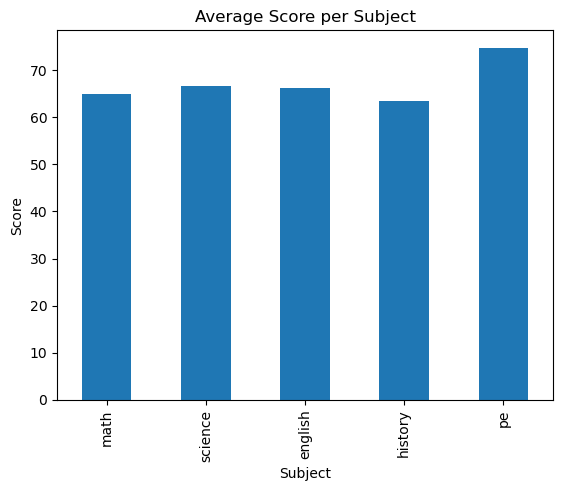

In [7]:
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1. Bar chart
avg_subject = df[subject_cols].mean()
plt.figure()
avg_subject.plot(kind='bar')
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Score")
plt.savefig("plot1_bar.png")
plt.show()


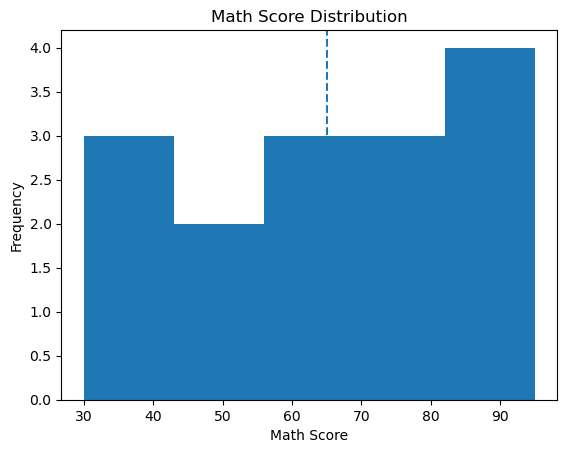

In [8]:
# 2. Histogram
plt.figure()
plt.hist(df['math'], bins=5)
mean_val = df['math'].mean()
plt.axvline(mean_val, linestyle='dashed')
plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.savefig("plot2_hist.png")
plt.show()

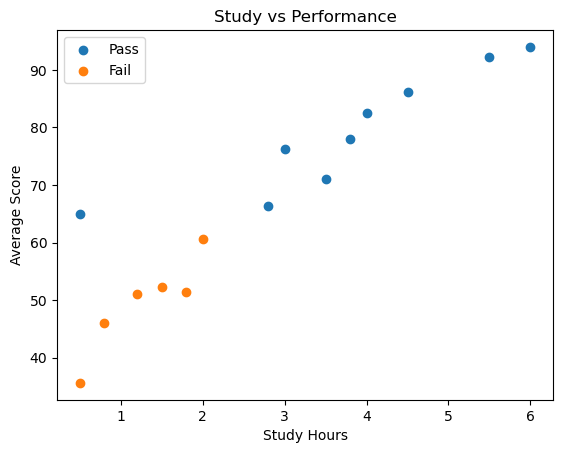

In [9]:
# 3. Scatter
plt.figure()
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.title("Study vs Performance")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_17564\3709911324.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


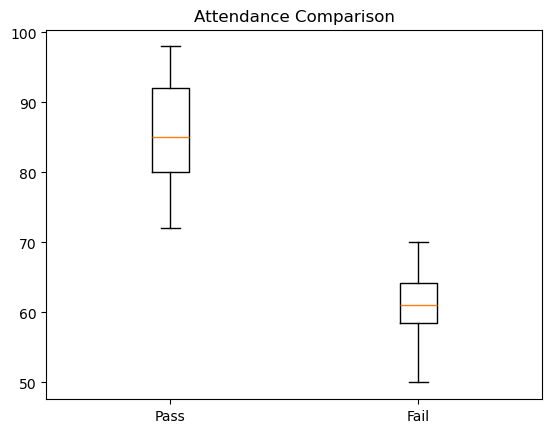

In [10]:
# 4. Boxplot
plt.figure()
plt.boxplot([
    pass_df['attendance_pct'],
    fail_df['attendance_pct']
], labels=["Pass", "Fail"])
plt.title("Attendance Comparison")
plt.savefig("plot4_box.png")
plt.show()

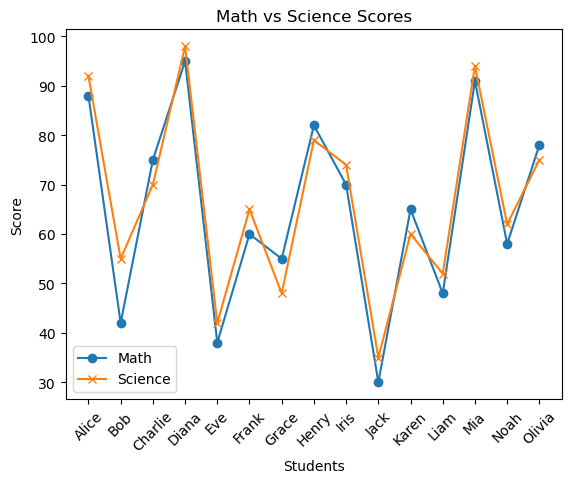

In [11]:
# 5. Line plot
plt.figure()
plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='x', label="Science")

plt.xticks(rotation=45)
plt.xlabel("Students")
plt.ylabel("Score")
plt.title("Math vs Science Scores")
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

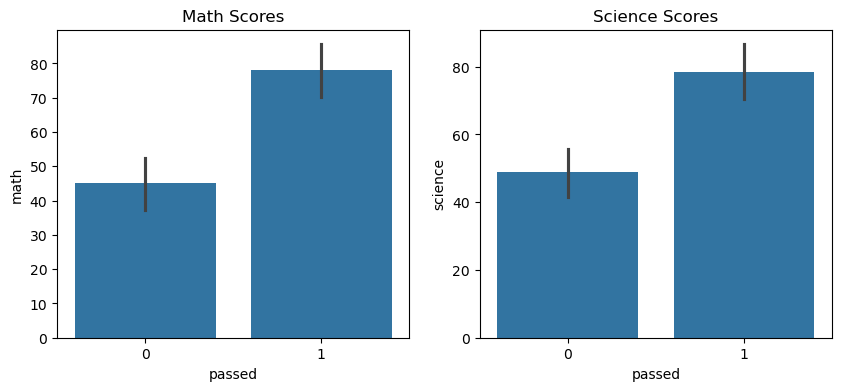

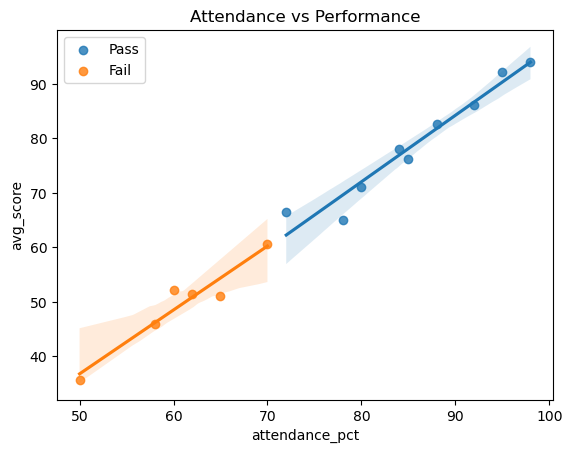

In [12]:
# TASK 3: SEABORN

import seaborn as sns

# Bar plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Math Scores")

sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Science Scores")

plt.savefig("plot6_seaborn_bar.png")
plt.show()


# Scatter + regression
plt.figure()

sns.regplot(data=df[df['passed'] == 1],
            x='attendance_pct', y='avg_score',
            label="Pass")

sns.regplot(data=df[df['passed'] == 0],
            x='attendance_pct', y='avg_score',
            label="Fail")

plt.legend()
plt.title("Attendance vs Performance")
plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# COMMENT:
# Seaborn is easier for statistical plots and requires less code.
# Matplotlib gives more control but needs more manual setup.

Training Accuracy: 1.0
Test Accuracy: 1.0
Jack | Actual: 0 | Pred: 0 ✅
Liam | Actual: 0 | Pred: 0 ✅
Alice | Actual: 1 | Pred: 1 ✅

Feature Importance:
english : 0.8646829738087998
attendance_pct : 0.5633908484125015
pe : 0.5043380745323413
math : 0.47121341488777024
science : 0.3545456312553088
history : 0.2837308196326748
study_hours_per_day : 0.15961710210101362


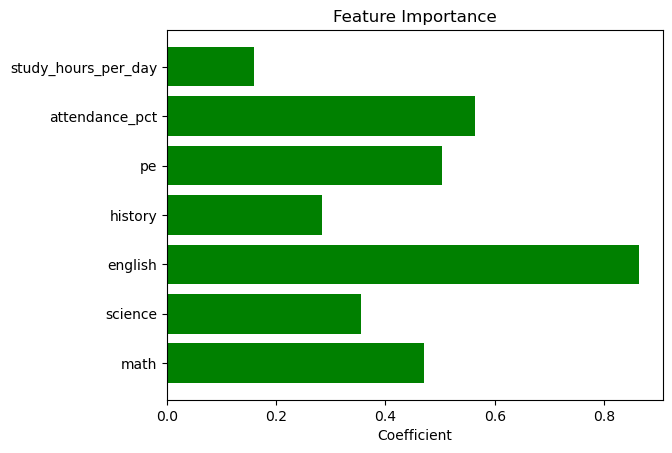


New Student Prediction: Pass
Probability: [[0.09442181 0.90557819]]


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [13]:
# TASK 4: MACHINE LEARNING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Features & target
X = df[['math', 'science', 'english', 'history', 'pe',
        'attendance_pct', 'study_hours_per_day']]
y = df['passed']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Training Accuracy:", model.score(X_train_scaled, y_train))

# Predict
y_pred = model.predict(X_test_scaled)
print("Test Accuracy:", model.score(X_test_scaled, y_test))

# Detailed results
names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    result = "✅" if actual == pred else "❌"
    print(name, "| Actual:", actual, "| Pred:", pred, result)


# Feature importance
import numpy as np

coeffs = model.coef_[0]
features = X.columns

pairs = sorted(zip(features, coeffs), key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance:")
for f, c in pairs:
    print(f, ":", c)


# Plot importance
plt.figure()
colors = ['green' if c > 0 else 'red' for c in coeffs]

plt.barh(features, coeffs, color=colors)
plt.title("Feature Importance")
plt.xlabel("Coefficient")
plt.savefig("plot8_feature_importance.png")
plt.show()


# Bonus: New student prediction
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)[0]
prob = model.predict_proba(new_scaled)

print("\nNew Student Prediction:", "Pass" if prediction == 1 else "Fail")
print("Probability:", prob)